# Aquaplanet with customized initial conditions

This notebook demonstrates how to change configuration of an aquaplanet simulation.

The code will be largely the same until the section "Customize Initial Condition" and "Run Couple Model".

In [1]:
from pathlib import Path

import jcm
from jcm.physics.speedy.speedy_coords import get_speedy_coords
from jcm.terrain import TerrainData
from jcm.forcing import ForcingData
from importlib import resources
import jax_datetime as jdt

from jem.components import JCM, SlabOceanModel, SlabSeaiceModel
from jem.components.slab.grid import generate_slab_grid
from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools

use_ipython = 'get_ipython' in globals()

/home/tienyiao/miniconda3/envs/jax/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configurations

In [2]:
start_datetime = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")
simulation_name = "01-02_aquaplanet_customized_initial_condition"
output_dir = (Path("output") / simulation_name).resolve()
output_dir.mkdir(exist_ok=True, parents=True)
output_figures = {
    "initial_condition": output_dir / "initial_sst.png",
    "animation": output_dir / "animation_humidity_sst.gif",
}
one_second = jdt.to_timedelta(1, "second")

## Creating Flux and Scalar Exchange between Components

In [3]:
def mapper(coupled_carry):
    atm = coupled_carry["atm"]
    ocn = coupled_carry["ocn"]
    seaice = coupled_carry["seaice"]

    ocn["forcing"].total_heat_flux = atm["derived"].total_heat_flux
    seaice["forcing"].ice_frazil_melt_energy = ocn["derived"].ice_frazil_melt_energy
    atm["forcing"].sea_surface_temperature = ocn["state"].sea_surface_temperature
    atm["forcing"].sice_am = seaice["derived"].ice_fraction

    return coupled_carry

## Create Components

In [4]:
atm_model = jcm.model.Model(
    coords=get_speedy_coords(),  # T31 spectral resolution with 8 vertical levels
    start_date=start_datetime,
)

atm_model = JCM.make_jem_compatible(
    atm_model,
    coupling_timestep=coupling_timestep,
)
# Aquaplanet: no mask_file, so fractional_mask defaults to all-zero (no land).
aquaplanet_grid = generate_slab_grid("JCM::T31")
model = Coupler(
    components=dict(
        atm=atm_model,
        ocn=SlabOceanModel(
            grid=aquaplanet_grid,
            start_datetime=start_datetime,
            timestep=coupling_timestep / one_second,
        ),
        seaice=SlabSeaiceModel(
            grid=aquaplanet_grid,
            start_datetime=start_datetime,
            timestep=coupling_timestep / one_second,
        ),
        seaice=SlabSeaiceModel(
            start_datetime=start_datetime,
            timestep=coupling_timestep / one_second,
        ),
    ),
    mappers=dict(mapper=mapper),
)

print("Model info: ") 
tree_tools.print_tree(model.get_info(), root="Model")

Notice: No fractional_mask given. Set fmask = 0.
Checking `initialize` => `collections.abc.Callable[[], typing.Any]`
Checking `generate_step_function` => `collections.abc.Callable[[], collections.abc.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `collections.abc.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `collections.abc.Callable[[], dict]`
Checking `initialize` => `collections.abc.Callable[[], typing.Any]`
Checking `generate_step_function` => `collections.abc.Callable[[], collections.abc.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `collections.abc.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `collections.abc.Callable[[], dict]`
Checking `initialize` => `collections.abc.Callable[[], typing.Any]`
Checking `generate_step_function` => `collections.abc.Callable[[], collections.abc.Callable[[typing.Any, float], tuple[typi

## Customize Initial Condition

In [5]:
import jax.numpy as jnp
customized_initial_coupled_carry = model.initialize()
ocean_carry = customized_initial_coupled_carry["ocn"]
ocean_model = model.components["ocn"].raw_component
ocean_carry["state"].sea_surface_temperature += 5 * jnp.sin(ocean_model.grid.longitude_radian * 2) * jnp.cos(ocean_model.grid.latitude_radian)**3

/home/tienyiao/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:126: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Boundary does not exist. Idealized initial SST will be used.


grid.bmask and SST_clim do share the same mask.
Notice: Climaology SST does not exist. Set relaxation time to inifinity.


Saving initial condition figure: /home/tienyiao/projects_local/project_jax-esm/jem_repo/jax-esm/examples/01_basic/output/01-02_aquaplanet_customized_initial_condition/initial_sst.png


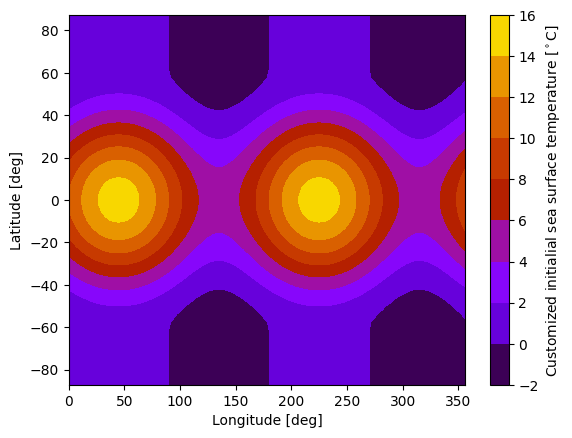

In [6]:
import matplotlib as mplt
if not use_ipython:
    mplt.use("Agg")
import matplotlib.pyplot as plt


lat = ocean_model.grid.latitude_radian[0, :] * 180.0 / jnp.pi
lon = ocean_model.grid.longitude_radian[:, 0] * 180.0 / jnp.pi
fig, ax = plt.subplots(1, 1)
mappable = ax.contourf(lon, lat, customized_initial_coupled_carry["ocn"]["state"].sea_surface_temperature.transpose() - 273.15, cmap="gnuplot")
cbar = plt.colorbar(mappable, ax=ax)
cbar.set_label("Customized initialial sea surface temperature [${}^\\circ \\mathrm{C}$]")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")

print(f"Saving initial condition figure: {output_figures['initial_condition']}")
plt.savefig(output_figures['initial_condition'], dpi=200)

if use_ipython:
    plt.show()


## Run Coupled Model

Use keyword `initial_carry` to set customized initial condition.

In [7]:
simulation_interval = jdt.to_timedelta(60, "day")
initial_state, final_state, predictions = model.run(
    initial_carry = customized_initial_coupled_carry,
    workflow=["mapper", "atm", "ocn", "seaice"],
    iterations = int(simulation_interval / coupling_timestep),
)

Flattened workflow:  mapper, atm, ocn, seaice
generate_trajectory_function took 0.03 seconds.


/home/tienyiao/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:126: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Using method: None


Simulation:   0%|                                                                                                                                                | 0/60 [00:00<?, ?it/s]

Simulation:   5%|██████▊                                                                                                                                 | 3/60 [00:00<00:02, 23.49it/s]

...

Simulation:  80%|████████████████████████████████████████████████████████████████████████████████████████████████████████████                           | 48/60 [00:02<00:00, 23.31it/s]

Simulation:  85%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                    | 51/60 [00:02<00:00, 23.31it/s]

Simulation:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌             | 54/60 [00:02<00:00, 23.31it/s]

Simulation:  95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎      | 57/60 [00:02<00:00, 23.31it/s]

Simulation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:02<00:00, 23.71it/s]

## Output into NetCDF

In [8]:
output_dict = model.predictions_to_xarray(predictions)
output_dict_subsample = {}
subsample_skip = 5
for component_name, ds in output_dict.items():
    output_file = output_dir / f"{component_name:s}.nc"
    print(f"Output file: {str(output_file)}, with subsample_skip = {subsample_skip:d}")
    ds = ds.isel(time=slice(None, None, subsample_skip))
    ds.to_netcdf(output_file, engine="netcdf4")
    output_dict_subsample[component_name] = ds

Output file: /home/tienyiao/projects_local/project_jax-esm/jem_repo/jax-esm/examples/01_basic/output/01-02_aquaplanet_customized_initial_condition/atm.nc, with subsample_skip = 5


Output file: /home/tienyiao/projects_local/project_jax-esm/jem_repo/jax-esm/examples/01_basic/output/01-02_aquaplanet_customized_initial_condition/ocn.nc, with subsample_skip = 5
Output file: /home/tienyiao/projects_local/project_jax-esm/jem_repo/jax-esm/examples/01_basic/output/01-02_aquaplanet_customized_initial_condition/seaice.nc, with subsample_skip = 5


## Visualization

Saving animation:  /home/tienyiao/projects_local/project_jax-esm/jem_repo/jax-esm/examples/01_basic/output/01-02_aquaplanet_customized_initial_condition/animation_humidity_sst.gif
Plotting frame=0


Plotting frame=0


Plotting frame=1


Plotting frame=2


Plotting frame=3


...

Plotting frame=7


Plotting frame=8


Plotting frame=9


Plotting frame=10


Plotting frame=11


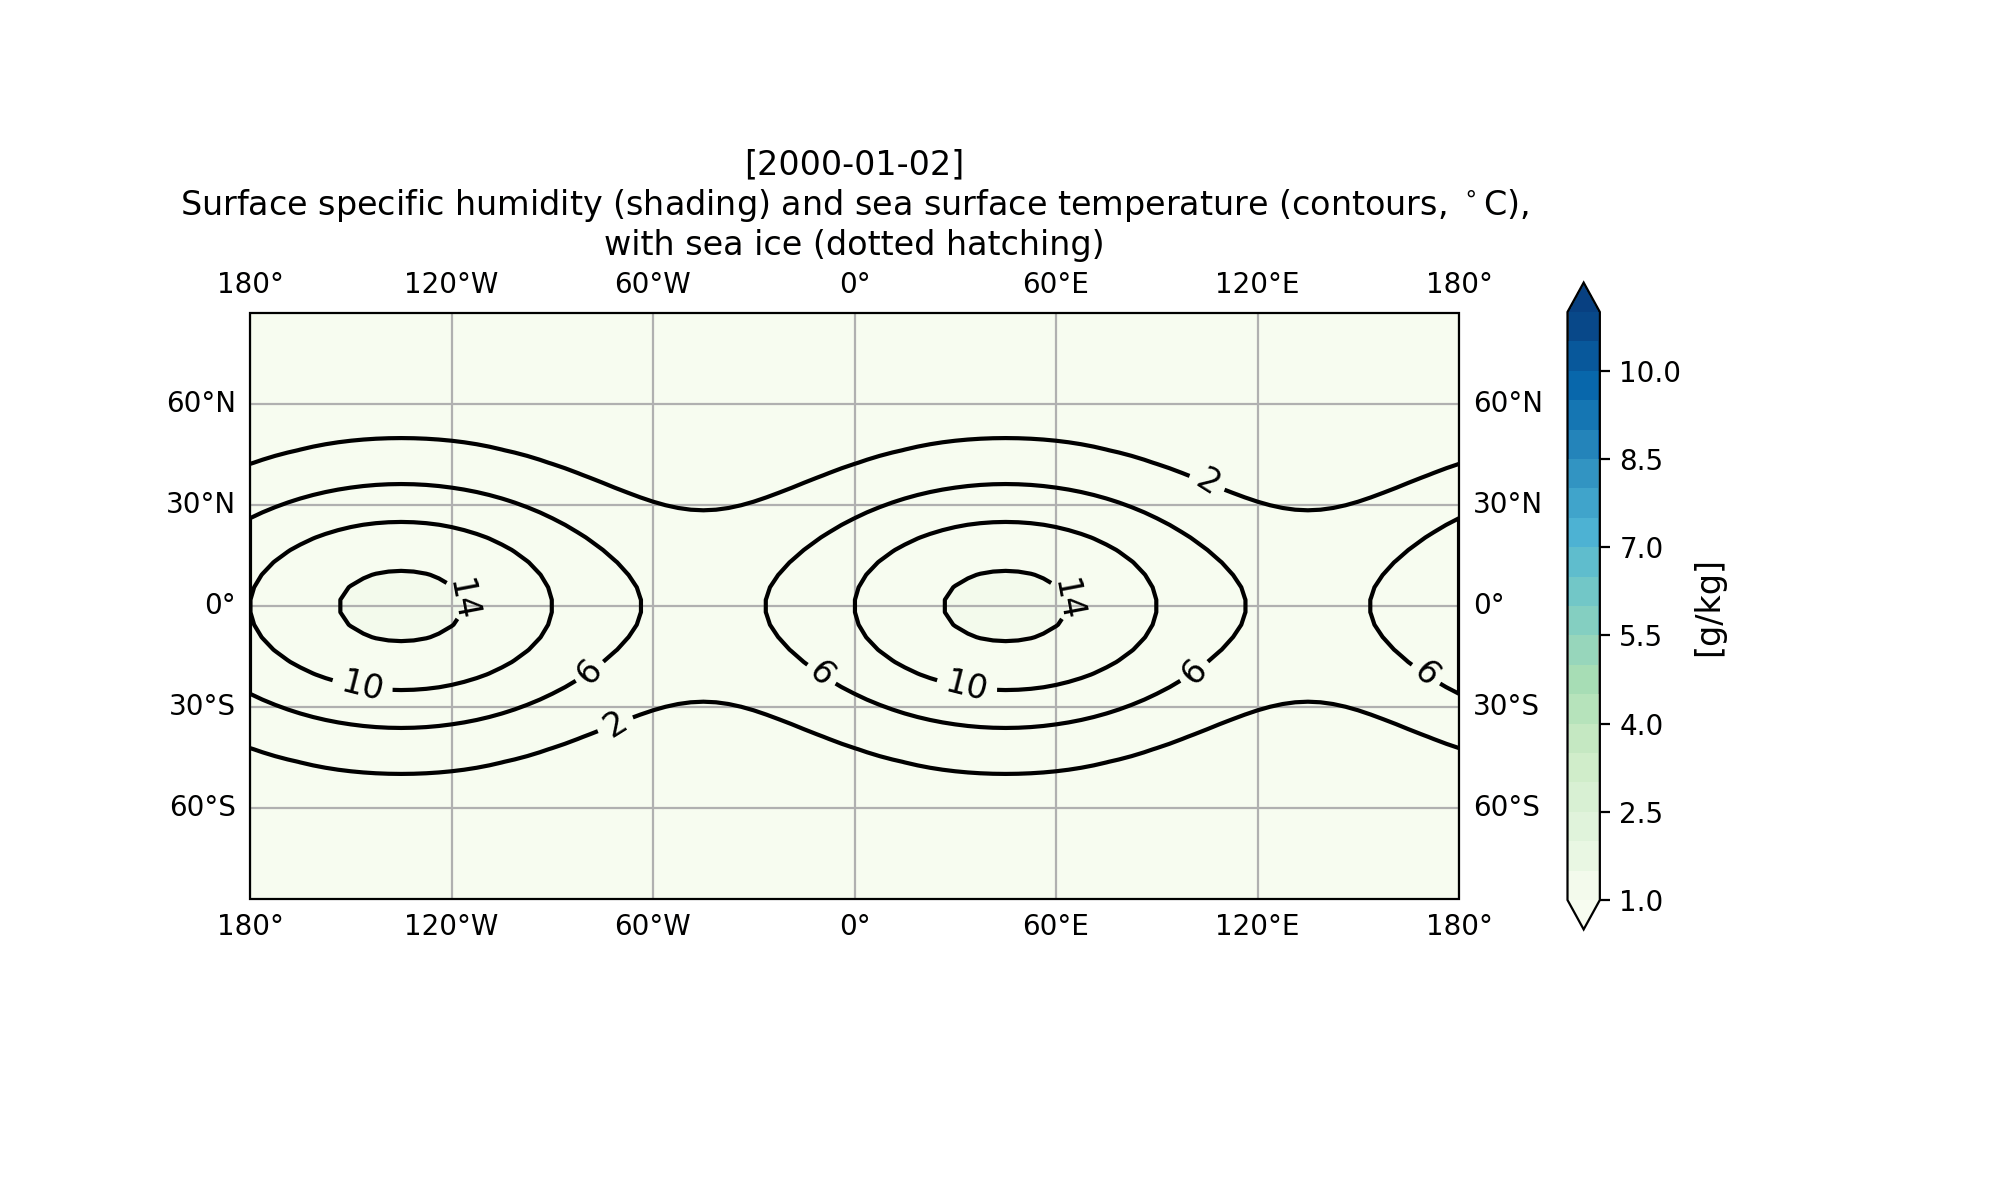

Plotting frame=0


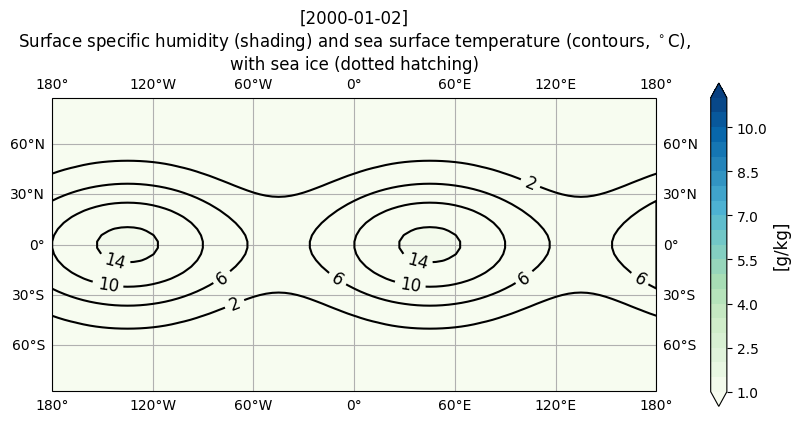

In [9]:

import matplotlib as mplt
if not use_ipython:
    mplt.use("Agg")

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import numpy as np

output_dict_animation = {
    component_name: _ds.isel(time=slice(None, None, 1))
    for component_name, _ds in output_dict_subsample.items()
}

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.gridlines(draw_labels=True)
cb = None
cf = None
cs = None
ch = None

def update(frame):
    print(f"Plotting frame={frame:d}")
    global cf, cb, cs, ch
    _data_q = output_dict_animation["atm"]["specific_humidity"].isel(time=frame, level=0)
    _data_sst = output_dict_animation["ocn"]["sea_surface_temperature"].isel(time=frame) - 273.15
    _data_sit = output_dict_animation["seaice"]["ice_thickness"].isel(time=frame)
    coords = _data_q.coords
    time_str = _data_q['time'].dt.strftime('%Y-%m-%d').to_numpy().item()
    lat = coords["lat"]
    lon = coords["lon"]

    # Remove previous frame's artists before drawing the new ones
    cf and cf.remove()
    cs and cs.remove()
    ch and ch.remove()
    
    # Plot the humidity field for the current time step
    cyclic_data_q, cyclic_lon = add_cyclic_point(_data_q.to_numpy().transpose(), coord=lon)
    mappable = ax.contourf(
        cyclic_lon, lat,
        cyclic_data_q,
        levels=1 + np.linspace(0, 1, 21) * 10,
        transform=ccrs.PlateCarree(), 
        cmap='GnBu',
        extend="both",
    )
    
    cyclic_data_sst, cyclic_lon = add_cyclic_point(_data_sst.to_numpy().transpose(), coord=lon)
    cs = ax.contour(
        cyclic_lon, lat,
        cyclic_data_sst,
        levels=np.arange(-2, 31, 4),
        transform=ccrs.PlateCarree(),
        colors="black",
    )
    ax.clabel(cs, fontsize=12)

    # Dot-hatch grid cells that carry any sea ice (thickness above zero)
    cyclic_data_sit, cyclic_lon = add_cyclic_point(_data_sit.to_numpy().transpose(), coord=lon)
    ch = ax.contourf(
        cyclic_lon, lat,
        cyclic_data_sit,
        levels=[1e-6, np.inf],
        colors="none",
        hatches=["."],
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(f"[{time_str:s}]\nSurface specific humidity (shading) and sea surface temperature (contours, ${{}}^\\circ \\mathrm{{C}}$),\nwith sea ice (dotted hatching)")
    if cb is None:
        cb = plt.colorbar(ax=ax, mappable=mappable, orientation='vertical', shrink=0.7, pad=0.07)
        cb.set_label("[g/kg]", fontsize=12)
    
    return [cf,]
    
# Generate and save
ani = FuncAnimation(fig, update, frames=len(output_dict_animation["atm"].coords["time"]), interval=120, blit=False)
print("Saving animation: ", output_figures["animation"])
ani.save(output_figures["animation"], writer='pillow', dpi=200)

if use_ipython:
    from IPython.display import Image
    display(Image(output_figures["animation"]))